# Trabajo Práctico 2 - Visión por Computadora I

Detector de máximo enfoque sobre un video, basado en análisis espectral (FFT), similar al usado por el autofocus de cámaras digitales.

Se implementa la métrica de nitidez propuesta en el paper *"Image Sharpness Measure for Blurred Images in Frequency Domain"* (De & Masilamani, 2013) y se la aplica sobre el video `focus_video.mov` en dos experimentos: midiendo sobre el frame completo y midiendo sobre una ROI central.

Resolución basada en los ejemplos de `Codigo/Clase3` (`03.Fourier.ipynb` y `04.Videos.ipynb`).

In [15]:
from pathlib import Path

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.figure import Figure
from scipy.signal import find_peaks

BASE: Path = Path('Material_TPs/TP2')
if not BASE.exists():
    BASE = Path('.')

VIDEO_PATH: Path = BASE / 'focus_video.mov'

## Métrica de nitidez (De & Masilamani, 2013)

El paper propone una medida de calidad de imagen (*FM*, Frequency Domain Image Blur Measure) que se basa en contar cuántas componentes de alta frecuencia tiene una imagen: una imagen nítida conserva muchas más componentes de alta frecuencia que una imagen desenfocada, ya que el desenfoque actúa como un filtro pasa bajos.

Algoritmo (para una imagen `I` de tamaño M×N en escala de grises):

1. Calcular `F`, la Transformada de Fourier 2D de `I`.
2. Centrar el espectro: `Fc = fftshift(F)`.
3. Calcular el módulo `AF = |Fc|`.
4. Calcular `M = max(AF)`.
5. Contar `T_H`, la cantidad de píxeles de `AF` cuyo valor supera el umbral `thres = M / 1000`.
6. `FM = T_H / (M × N)`.

Cuanto mayor es `FM`, más nítida (enfocada) está la imagen.

In [16]:
def medida_enfoque_fd(gray: np.ndarray, umbral_rel: float = 1 / 1000) -> float:
    """Frequency Domain Image Blur Measure (De & Masilamani, 2013)."""
    F: np.ndarray = np.fft.fft2(gray.astype(np.float64))
    Fc: np.ndarray = np.fft.fftshift(F)
    AF: np.ndarray = np.abs(Fc)
    umbral: float = AF.max() * umbral_rel
    T_H: int = np.count_nonzero(AF > umbral)
    return T_H / AF.size


def espectro_mod(gray: np.ndarray) -> np.ndarray:
    """Espectro de Fourier centrado, en escala logarítmica (para visualización)."""
    F: np.ndarray = np.fft.fftshift(np.fft.fft2(gray.astype(np.float64)))
    return 20 * np.log(np.abs(F) + 1)

## Carga del video

Se leen todos los frames una única vez y se guardan en escala de grises, para reutilizarlos en ambos experimentos sin volver a decodificar el video.

In [17]:
cap: cv.VideoCapture = cv.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise OSError(f'No se pudo abrir el video: {VIDEO_PATH}')

fps: float = cap.get(cv.CAP_PROP_FPS)
frames_gray: list[np.ndarray] = []
while True:
    ret: bool
    frame: np.ndarray
    ret, frame = cap.read()
    if not ret:
        break
    frames_gray.append(cv.cvtColor(frame, cv.COLOR_BGR2GRAY))
cap.release()

n_frames: int = len(frames_gray)
alto: int
ancho: int
alto, ancho = frames_gray[0].shape
print(f'Frames: {n_frames}, tamaño: {ancho}x{alto} px, fps: {fps:.2f}')

Frames: 171, tamaño: 640x360 px, fps: 29.97


## Detección automática del punto de máximo enfoque

Para detectar de forma automática el (o los) frame de máximo enfoque, se buscan picos locales en la curva de `FM` con `scipy.signal.find_peaks`, exigiendo una prominencia mínima proporcional al rango de la curva. Esto emula el barrido que hace el autofocus de una cámara: mueve la lente, mide la nitidez en cada paso, y se queda con el máximo detectado.

In [18]:
def detectar_picos_enfoque(
    metric: np.ndarray, prominence_ratio: float = 0.3, **kwargs: object
) -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Devuelve los índices de frame donde la métrica de enfoque tiene un máximo local."""
    prominencia: float = (metric.max() - metric.min()) * prominence_ratio
    picos: np.ndarray
    props: dict[str, np.ndarray]
    picos, props = find_peaks(metric, prominence=prominencia, **kwargs)
    return picos, props

## Experimento 1: medición sobre todo el frame

In [19]:
metric_full: np.ndarray = np.array([medida_enfoque_fd(g) for g in frames_gray])
picos_full: np.ndarray
props_full: dict[str, np.ndarray]
picos_full, props_full = detectar_picos_enfoque(metric_full)

print('Frame(s) de máximo enfoque (frame completo):', picos_full)
print('Valor de FM en esos frames:', metric_full[picos_full])

Frame(s) de máximo enfoque (frame completo): [109]
Valor de FM en esos frames: [0.02824219]


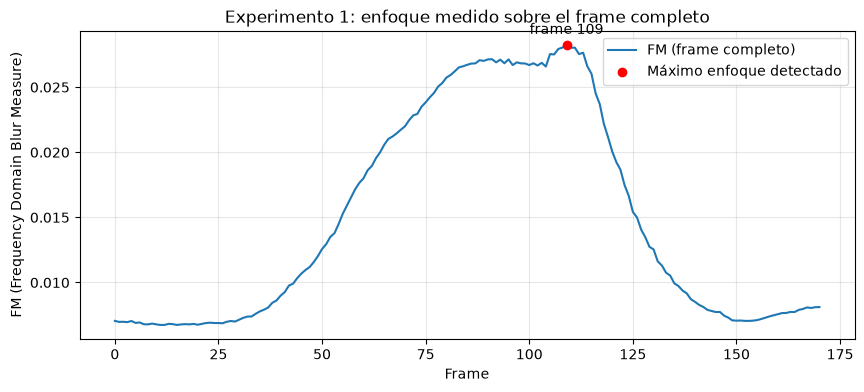

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(metric_full, label='FM (frame completo)')
plt.scatter(picos_full, metric_full[picos_full], color='red', zorder=5,
            label='Máximo enfoque detectado')
for p in picos_full:
    plt.annotate(f'frame {p}', (p, metric_full[p]), textcoords='offset points',
                 xytext=(0, 8), ha='center')
plt.xlabel('Frame')
plt.ylabel('FM (Frequency Domain Blur Measure)')
plt.title('Experimento 1: enfoque medido sobre el frame completo')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Análisis

La curva tiene una única forma de "campana": arranca desenfocada, crece monótonamente hasta un máximo y luego vuelve a decaer. Esto es consistente con un barrido de foco (*focus rack*) donde la lente pasa de estar desenfocada, a enfocar el sujeto, y luego se sigue desenfocando. El algoritmo de detección de picos ubica correctamente el máximo global de la curva sin necesidad de fijar el valor a mano.

### Verificación visual

Se muestran el frame más desenfocado y el de máximo enfoque detectado, junto con su espectro de Fourier centrado (en escala logarítmica). Tal como se describe en el paper, el frame enfocado concentra muchas más componentes de alta frecuencia (puntos brillantes alejados del centro del espectro) que el frame desenfocado.

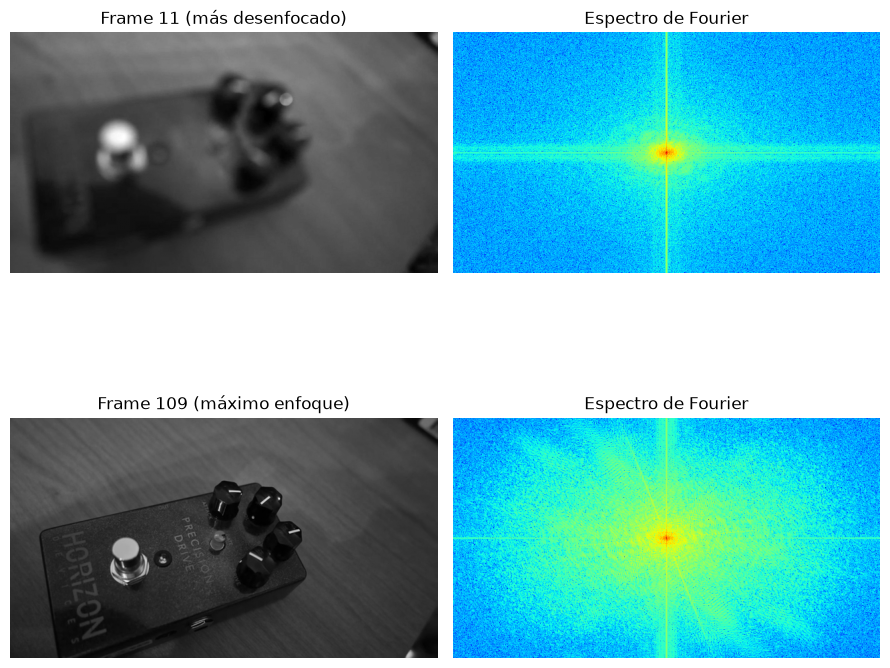

In [21]:
frame_max: int = int(picos_full[np.argmax(metric_full[picos_full])])
frame_min: int = int(np.argmin(metric_full))

fig: Figure
axes: np.ndarray
fig, axes = plt.subplots(2, 2, figsize=(9, 9))

axes[0, 0].imshow(frames_gray[frame_min], cmap='gray')
axes[0, 0].set_title(f'Frame {frame_min} (más desenfocado)')

axes[0, 1].imshow(espectro_mod(frames_gray[frame_min]), cmap='jet')
axes[0, 1].set_title('Espectro de Fourier')

axes[1, 0].imshow(frames_gray[frame_max], cmap='gray')
axes[1, 0].set_title(f'Frame {frame_max} (máximo enfoque)')

axes[1, 1].imshow(espectro_mod(frames_gray[frame_max]), cmap='jet')
axes[1, 1].set_title('Espectro de Fourier')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

## Experimento 2: medición sobre una ROI central (10% del área)

Se define una ROI centrada en el frame cuya área equivale al 10% del área total, conservando la relación de aspecto del frame (factor de escala lineal = √0.10).

In [22]:
def roi_centrada(
    ancho: int, alto: int, area_ratio: float = 0.10
) -> tuple[int, int, int, int]:
    escala: float = np.sqrt(area_ratio)
    w_roi: int = round(ancho * escala)
    h_roi: int = round(alto * escala)
    x0: int = (ancho - w_roi) // 2
    y0: int = (alto - h_roi) // 2
    return x0, y0, w_roi, h_roi


x0: int
y0: int
w_roi: int
h_roi: int
x0, y0, w_roi, h_roi = roi_centrada(ancho, alto, area_ratio=0.10)
area_pct: float = 100 * (w_roi * h_roi) / (ancho * alto)
print(f'ROI: {w_roi}x{h_roi} px ({area_pct:.1f}% del área), '
      f'esquina superior izquierda ({x0},{y0})')

ROI: 202x114 px (10.0% del área), esquina superior izquierda (219,123)


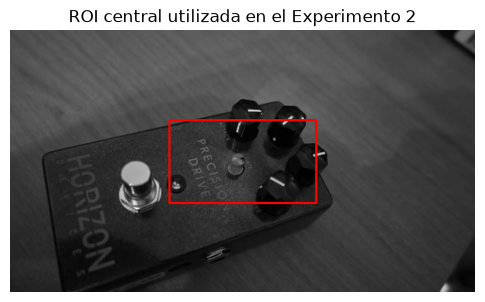

In [23]:
frame_ejemplo: np.ndarray = cv.cvtColor(frames_gray[frame_max], cv.COLOR_GRAY2BGR)
cv.rectangle(frame_ejemplo, (x0, y0), (x0 + w_roi, y0 + h_roi), (0, 0, 255), 2)

plt.figure(figsize=(6, 4))
plt.imshow(cv.cvtColor(frame_ejemplo, cv.COLOR_BGR2RGB))
plt.title('ROI central utilizada en el Experimento 2')
plt.axis('off')
plt.show()

In [24]:
metric_roi: np.ndarray = np.array([
    medida_enfoque_fd(g[y0:y0 + h_roi, x0:x0 + w_roi])
    for g in frames_gray
])
picos_roi: np.ndarray
props_roi: dict[str, np.ndarray]
picos_roi, props_roi = detectar_picos_enfoque(metric_roi)

print('Frame(s) de máximo enfoque (ROI central):', picos_roi)
print('Valor de FM en esos frames:', metric_roi[picos_roi])

Frame(s) de máximo enfoque (ROI central): [111]
Valor de FM en esos frames: [0.35643564]


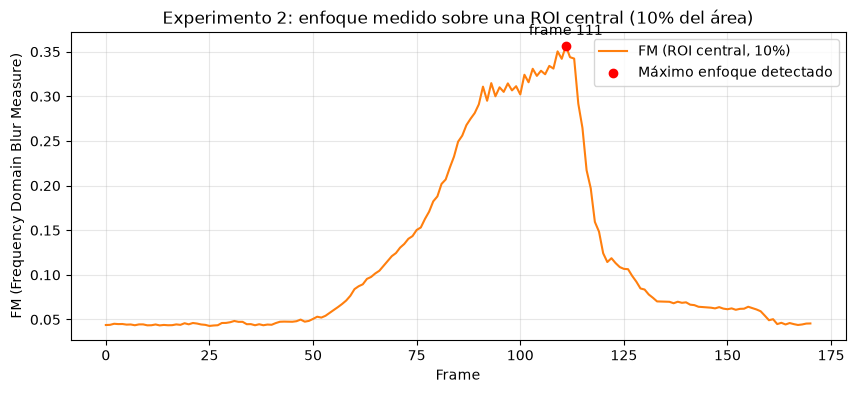

In [25]:
plt.figure(figsize=(10, 4))
plt.plot(metric_roi, label='FM (ROI central, 10%)', color='tab:orange')
plt.scatter(picos_roi, metric_roi[picos_roi], color='red', zorder=5,
            label='Máximo enfoque detectado')
for p in picos_roi:
    plt.annotate(f'frame {p}', (p, metric_roi[p]), textcoords='offset points',
                 xytext=(0, 8), ha='center')
plt.xlabel('Frame')
plt.ylabel('FM (Frequency Domain Blur Measure)')
plt.title('Experimento 2: enfoque medido sobre una ROI central (10% del área)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

### Comparación entre ambos experimentos

Se superponen ambas curvas normalizadas (min-max) para comparar la forma y la ubicación del máximo detectado en cada caso.

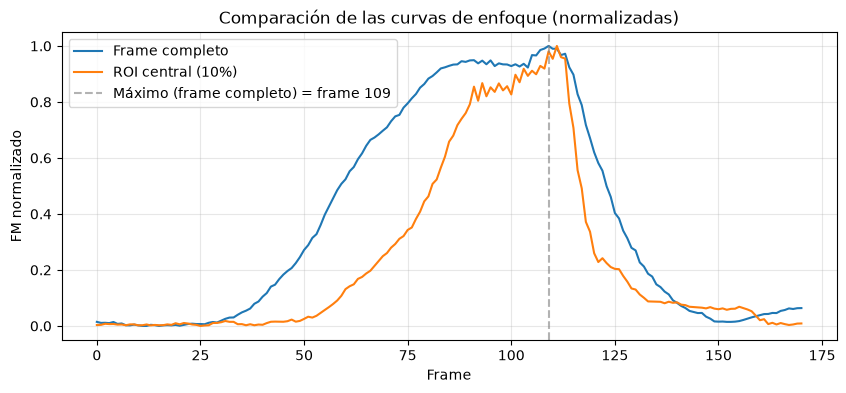

Máximo enfoque - frame completo: [109] -> frame 109
Máximo enfoque - ROI central   : [111]


In [26]:
def normalizar(x: np.ndarray) -> np.ndarray:
    return (x - x.min()) / (x.max() - x.min())


plt.figure(figsize=(10, 4))
plt.plot(normalizar(metric_full), label='Frame completo')
plt.plot(normalizar(metric_roi), label='ROI central (10%)')
plt.axvline(frame_max, color='gray', linestyle='--', alpha=0.6,
            label=f'Máximo (frame completo) = frame {frame_max}')
plt.xlabel('Frame')
plt.ylabel('FM normalizado')
plt.title('Comparación de las curvas de enfoque (normalizadas)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print('Máximo enfoque - frame completo:', picos_full, '-> frame', frame_max)
print('Máximo enfoque - ROI central   :', picos_roi)

### Análisis

Ambas curvas tienen la misma forma de campana y el máximo se detecta prácticamente en el mismo instante en los dos experimentos (a menos de un par de frames de diferencia, es decir, unas pocas decenas de milisegundos a ~30 fps). Esto tiene sentido porque el sujeto sobre el que se enfoca la cámara está ubicado en el centro del frame, que es justamente la zona que cubre la ROI.

La curva de la ROI es más "ruidosa" (variación relativa mayor entre frames vecinos) que la del frame completo, porque al usar muchos menos píxeles el conteo de componentes de alta frecuencia `T_H` es más sensible a pequeños cambios de contenido o de ruido de la cámara. A cambio, medir sobre una ROI central tiene ventajas prácticas: reduce drásticamente el costo computacional de la FFT (mucho menos píxeles a transformar) y concentra la medición en la región donde normalmente se ubica el sujeto de interés, evitando que el fondo (que puede desenfocarse o enfocarse de forma distinta al sujeto) distorsione la métrica. Esto es análogo a los sistemas de autofocus "center-weighted" o de zona que usan las cámaras digitales reales.

En este video en particular, donde el desenfoque es uniforme sobre toda la escena (barrido de foco de la lente), ambos enfoques llevan a la misma conclusión: el punto de máximo enfoque detectado automáticamente está en el entorno del frame 110 (~3.6 s de video, a 29.97 fps).